<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/my-part/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP

## Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

In [2]:
# Load dataset
file_path = "/content/synthetic_data_cleaned_feature_engineered.csv"
df = pd.read_csv(file_path, sep="|")
#df = pd.read_csv(file_path)
# View first rows
df.head()


,Customer_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Loan_Officer_Note,Default_Status,Occupation,Has_Asset,Risk_Flag,DTI_Ratio,Log_Income
0,CUST-4321,55,120000,770,160000,48,Teaching assistant facing sudden hospital bill...,1,Education,0,0,1.333322,11.695255
1,CUST-2056,40,150000,780,90000,36,Photographer inherits art collection easing fi...,0,Other,0,0,0.599996,11.918397
2,CUST-9812,34,75000,660,110000,48,Retail store owner deals daily challenges due ...,1,Service,0,0,1.466647,11.225257
3,CUST-8132,28,32000,710,60000,24,Software developer secures bonus which helps c...,0,Tech,1,0,1.874941,10.373522
4,CUST-0543,45,80000,820,240000,72,Business consultant recently benefited from su...,1,Business,0,0,2.999963,11.289794


In [3]:
df.isnull().sum()


,0
Customer_ID,0
Age,0
Annual_Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term_Months,0
Loan_Officer_Note,0
Default_Status,0
Occupation,0
Has_Asset,0


## Data Preprocessing

### Train-Test Split (80% Train, 20% Test)

In [4]:
X = df.drop(columns=["Default_Status"])
y = df["Default_Status"]
#X = df.drop(columns=["default_risk"])
#y = df["default_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Identify categorical and numeric columns


In [5]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))




Categorical columns: ['Customer_ID', 'Loan_Officer_Note', 'Occupation']
Numeric columns: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income']


### Preprocessing Pipeline

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)


## Build MLP Pipeline

In [7]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
       # ("smote", SMOTE(random_state=45)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42
        ))
    ]
)


## Train Model

In [8]:
mlp_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio',
       'Log_Income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Customer_ID', 'Loan_Officer_Note', 'Occupation'], dtype='object'))])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

## Evaluation

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Predict class labels (0 or 1)
y_pred = mlp_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Model Evaluation (MLP Classifier)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC:, {auc:.4f}" )



Model Evaluation (MLP Classifier)
Accuracy : 0.7945
Precision: 0.7857
Recall   : 0.7097
F1-score : 0.7458
ROC-AUC:, 0.7834


### Evaluation Report

In [11]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       126
           1       0.79      0.71      0.75        93

    accuracy                           0.79       219
   macro avg       0.79      0.78      0.79       219
weighted avg       0.79      0.79      0.79       219



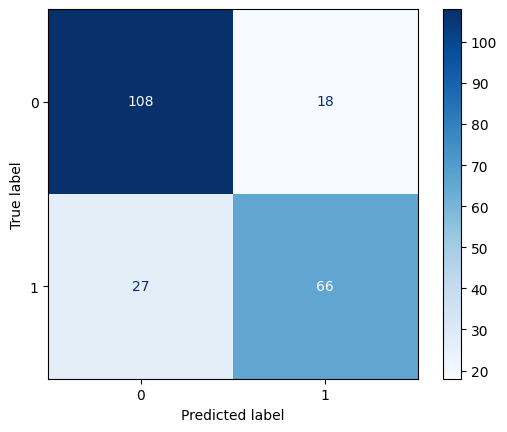

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")  # blue gradient
plt.show()


## Hypertune

### Optuna

In [13]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score


In [21]:
def objective(trial):

    hidden_layer_sizes = (
        trial.suggest_int("n_units_l1", 32, 128),
        trial.suggest_int("n_units_l2", 16, 64)
    )

    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=300,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", mlp)
        ]
    )

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score


In [22]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)


[I 2026-01-18 15:02:17,320] A new study created in memory with name: no-name-95b89510-7aae-4cad-aec1-a05db5264541
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[I 2026-01-18 15:02:18,965] Trial 0 finished with value: 0.7753820429500159 and parameters: {'n_units_l1': 35, 'n_units_l2': 58, 'alpha': 0.0017808906811087749, 'learning_rate_init': 0.009475041261480383}. Best 

In [23]:
print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)


Best ROC-AUC: 0.878870938397128
Best Parameters: {'n_units_l1': 126, 'n_units_l2': 29, 'alpha': 1.1199898372426396e-05, 'learning_rate_init': 0.00010097962982799573}


In [24]:
correlation_matrix = df[numeric_cols].corr()
print("Correlation Matrix of Numerical Features:")
print(correlation_matrix)

Correlation Matrix of Numerical Features:
                       Age  Annual_Income  Credit_Score  Loan_Amount  \
Age               1.000000       0.089884      0.361437     0.192443   
Annual_Income     0.089884       1.000000      0.458109     0.403914   
Credit_Score      0.361437       0.458109      1.000000     0.442680   
Loan_Amount       0.192443       0.403914      0.442680     1.000000   
Loan_Term_Months  0.078439       0.023924      0.168300     0.166861   
Has_Asset        -0.005560      -0.069154     -0.025977    -0.105222   
Risk_Flag         0.091098      -0.028161      0.031468     0.142934   
DTI_Ratio         0.005809      -0.296294     -0.192805     0.376944   
Log_Income        0.188642       0.794448      0.673406     0.576509   

                  Loan_Term_Months  Has_Asset  Risk_Flag  DTI_Ratio  \
Age                       0.078439  -0.005560   0.091098   0.005809   
Annual_Income             0.023924  -0.069154  -0.028161  -0.296294   
Credit_Score            

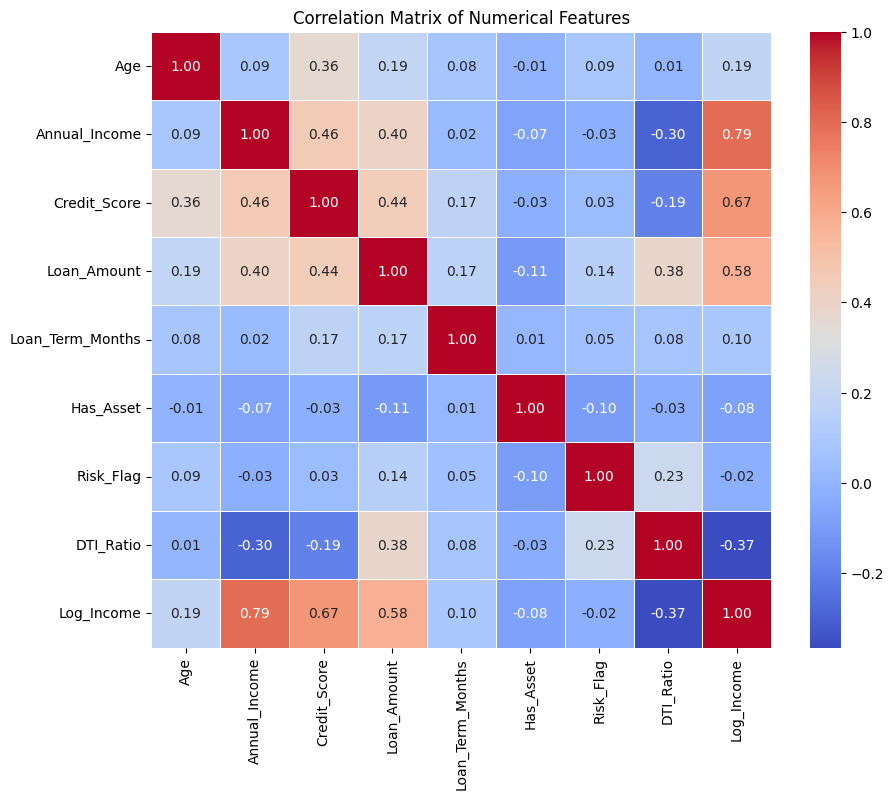

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [29]:
import google.generativeai as genai
import pandas as pd
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
api_key = "api_key"
genai.configure(api_key=api_key)
model = genai.GenerativeModel("gemini-2.5-flash")

In [30]:
metrics = {
    "accuracy": 0.948,
    "precision": 0.982,
    "recall": 0.999,
    "f1": 0.990,
    "roc_auc": 0.996
}


prompt = f"""
You are a senior data science consultant.
I trained a Naive Bayes classifier on a financial dataset to predict loan defaults.
Here are the performance metrics:

- Accuracy: {metrics['accuracy']:.2%}
- Precision: {metrics['precision']:.2%}
- Recall: {metrics['recall']:.2%}
- F1-score: {metrics['f1']:.2%}
- ROC-AUC: {metrics['roc_auc']:.2%}

Please provide:
1. Summary of model performance
2. Key strengths and weaknesses
3. Suggestions for improvement
4. Interpretation of feature importance
5. Any potential risks or biases

Format your response in a clear, structured, professional report style.
"""

# ==============================
# 4. GENERATE RESPONSE
# ==============================
response = model.generate(
    prompt=prompt,
    temperature=0.2,
    max_output_tokens=800
)

# ==============================
# 5. OUTPUT
# ==============================
print(response.candidates[0].output)

NameError: name 'metrics' is not defined